In [1]:
import numpy as np
import bilby
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner
import json
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib import rc
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18

In [2]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [3]:
default_kwargs = dict(
    bins=100,
    smooth=2,
    smooth1d=2,

    title_fmt='.1f',
    title_kwargs=dict(fontsize=18, pad=2),
    label_kwargs=dict(color='black', fontsize=18),

    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_density=False,
    plot_datapoints=False,
    max_n_ticks=3,
    labelpad=-0.02
)

In [4]:
cosmo_corner_lbs = [r'$H_0\,[\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}]$',
              r'$\Omega_{m,0}$', 
              r'$\gamma$', 
              r'$\kappa$', 
              r'$z_p$',
              r'$b_{\rm GW}$',
              r'$\alpha_{\rm GW}$']
cosmo_title_labels = [r'$H_0$',
              r'$\Omega_{m,0}$', 
              r'$\gamma$', 
              r'$\kappa$', 
              r'$z_p$',
              r'$b_{\rm GW}$',
              r'$\alpha_{\rm GW}$']

In [5]:
def plot_corner(ref_data, label, injected_values, labels=cosmo_corner_lbs, title_labels=cosmo_title_labels, lbl_size=16):
    figure = corner.corner(ref_data, 
                           titles = title_labels, labels = labels,
                           color=ska_color_purple, alpha=0.5,
                           range=[(40, 100), (0, 1), (1, 5), (2.5, 9), (0.75, 1.25), (0, 3.5), (-1, 1)],  # one tuple per parameter
                           rect=[0, 0, 1, 1], 
                           fill_contours=True,
                           show_titles=True,
                           truths=injected_values,
                           truth_color=ska_color_pink,
                           title_quantiles=[0.16, 0.5, 0.84],
                           quantiles=[0.16, 0.84],
                           hist_kwargs={"linewidth": 2.},      
                           contour_kwargs={"alpha": 0.45},
                           figsize=(6,4), **default_kwargs)
    for ax in figure.get_axes():
        ax.tick_params(axis = 'both', labelsize = lbl_size)

    figure.subplots_adjust(wspace=0, hspace=0)
    legend_elements = [
        Line2D(
        [0], [0],
        color=ska_color_pink,
        lw=3.5,
        linestyle="solid",
        label=r"\rm Injected value"
    ),
    Patch(facecolor=ska_color_purple, label=r"\rm Clustered GWs - {\textrm{H\textsc{i}}}", alpha=1),
    ]

    figure.legend(handles=legend_elements, bbox_to_anchor=(0.95, 0.8), fontsize=23, frameon=False)
    plt.subplots_adjust(left=0.2, bottom=0.2, right=0.95, top=0.95)
    plt.savefig(f'corner_{label}_bias.pdf', bbox_inches='tight')
    plt.show()

In [6]:
params = ['H0', 'Om0', 'gamma', 'kappa', 'zp', 'bGW', 'alphaGW']
injected_values = [67.7, 0.308, 2.7, 6, 1, 1, 0]

In [7]:
ref_data = bilby.result.read_in_result('../../results/cosmoPEs_snr150_rs1_nside16_HIHI_bias_params/label_result.json')

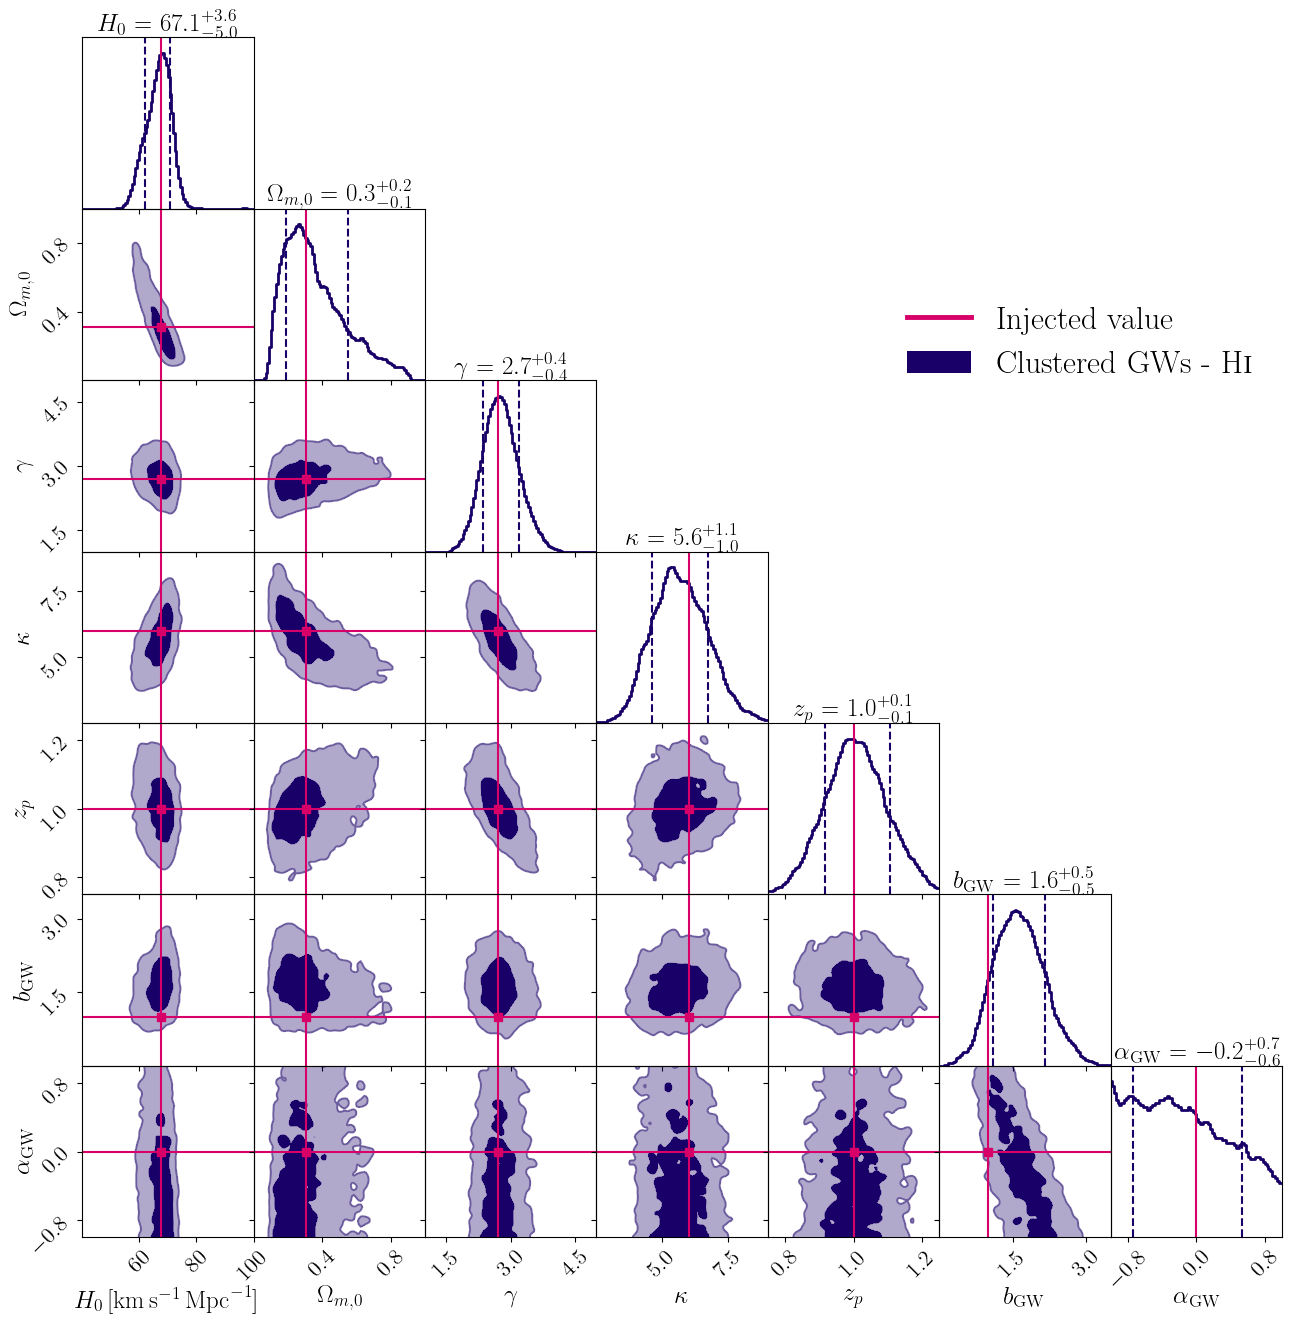

In [8]:
fig = plot_corner(ref_data.posterior[params], 'headline_bias', injected_values)